Goal of the Analysis

The primary goal of this analysis is to derive actionable insights from the CRM sales opportunities dataset. This involves understanding sales performance, identifying key factors contributing to successful deals, and examining trends that influence deal outcomes. Specifically, the analysis aims to:

1.	Evaluate Sales Performance:
	Identify the top-performing sales agents and regional offices based on revenue and deal closures.
	Determine the products, sectors, and time periods (e.g., months or years) that contribute most to sales success.
2.	Analyze Customer and Deal Characteristics:
	Explore customer-related factors, such as revenue and employee size, to understand their relationship with deal outcomes.
	Examine the sales cycle duration to assess the efficiency of the sales process.
3.	Visualize Key Sales Trends and Patterns:
	Understand the distribution of deal stages (e.g., Won vs. Lost) and analyze sales trends over time.
	Investigate the monthly and yearly distribution of deals to identify seasonal or temporal patterns.
4.	Inform Strategy and Decision-Making:
	Use the insights to improve sales strategy, optimize product focus, enhance sales cycle efficiency, and prioritize high-value customers and sectors.


In [1]:
#importing libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#read data into df
df=pd.read_csv("CRM sales opportunity.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8806 entries, 0 to 8805
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   opportunity_id    8800 non-null   object 
 1   sales_agent       8805 non-null   object 
 2   product           8801 non-null   object 
 3   account           7375 non-null   object 
 4   deal_stage        8800 non-null   object 
 5   engage_date       8300 non-null   object 
 6   close_date        6711 non-null   object 
 7   close_value       6711 non-null   float64
 8   sector            7375 non-null   object 
 9   year_established  7375 non-null   float64
 10  revenue           7375 non-null   float64
 11  employees         7375 non-null   float64
 12  office_location   7375 non-null   object 
 13  subsidiary_of     1292 non-null   object 
 14  manager           8805 non-null   object 
 15  regional_office   8805 non-null   object 
 16  series            7321 non-null   object 


# Data Cleaning

In [3]:
#summing null values in each column
df.isnull().sum()

opportunity_id         6
sales_agent            1
product                5
account             1431
deal_stage             6
engage_date          506
close_date          2095
close_value         2095
sector              1431
year_established    1431
revenue             1431
employees           1431
office_location     1431
subsidiary_of       7514
manager                1
regional_office        1
series              1485
sales_price         1485
dtype: int64

In [4]:
#drop column subsidiary since it wont be needed in the analysis
df=df.drop(columns=["subsidiary_of"])

In [5]:
df.columns

Index(['opportunity_id', 'sales_agent', 'product', 'account', 'deal_stage',
       'engage_date', 'close_date', 'close_value', 'sector',
       'year_established', 'revenue', 'employees', 'office_location',
       'manager', 'regional_office', 'series', 'sales_price'],
      dtype='object')

In [6]:
#fill null values with the median 
fill_median = [ 'year_established', 'employees']
df[fill_median] = df[fill_median].fillna(df[fill_median].median())


In [7]:
#fill null values with 0
fill_0 = ['revenue','close_value','sales_price']
df[fill_0] = df[fill_0].fillna(0)

In [8]:
df.isnull().sum()

opportunity_id         6
sales_agent            1
product                5
account             1431
deal_stage             6
engage_date          506
close_date          2095
close_value            0
sector              1431
year_established       0
revenue                0
employees              0
office_location     1431
manager                1
regional_office        1
series              1485
sales_price            0
dtype: int64

In [9]:
#changing data type
df["close_date"]=pd.to_datetime(df["close_date"]).dt.date
df["engage_date"]=pd.to_datetime(df["engage_date"]).dt.date
df["year_established"]=pd.to_datetime(df["year_established"]).dt.year
df["close_value"]=df["close_value"].astype(int)
df["employees"]=df["employees"].astype(int)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8806 entries, 0 to 8805
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   opportunity_id    8800 non-null   object 
 1   sales_agent       8805 non-null   object 
 2   product           8801 non-null   object 
 3   account           7375 non-null   object 
 4   deal_stage        8800 non-null   object 
 5   engage_date       8300 non-null   object 
 6   close_date        6711 non-null   object 
 7   close_value       8806 non-null   int32  
 8   sector            7375 non-null   object 
 9   year_established  8806 non-null   int64  
 10  revenue           8806 non-null   float64
 11  employees         8806 non-null   int32  
 12  office_location   7375 non-null   object 
 13  manager           8805 non-null   object 
 14  regional_office   8805 non-null   object 
 15  series            7321 non-null   object 
 16  sales_price       8806 non-null   float64


In [11]:
df.head(20)

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,sector,year_established,revenue,employees,office_location,manager,regional_office,series,sales_price
0,4MXSHU7X,Corliss Cosme,GTK 500,Kan-code,Lost,2017-10-22,2017-11-30,0,software,1970,11698.03,34288,United States,Cara Losch,East,GTK,26768.0
1,PP4ZY6TZ,Darcel Schlecht,GTK 500,Treequote,Lost,2017-10-27,2017-11-10,0,telecommunications,1970,5266.09,8595,United States,Melvin Marxen,Central,GTK,26768.0
2,IXOHJYRM,Elease Gluck,GTK 500,Cheers,Lost,2017-02-02,2017-05-09,0,entertainment,1970,4269.90,6472,United States,Celia Rouche,West,GTK,26768.0
3,PEX6S873,Elease Gluck,GTK 500,Cheers,Lost,2017-03-15,2017-05-19,0,entertainment,1970,4269.90,6472,United States,Celia Rouche,West,GTK,26768.0
4,6X4EEUGA,Elease Gluck,GTK 500,Cheers,Won,2017-06-15,2017-06-30,25464,entertainment,1970,4269.90,6472,United States,Celia Rouche,West,GTK,26768.0
5,H3K2E35I,Elease Gluck,GTK 500,Cheers,Won,2017-10-28,2017-10-29,27971,entertainment,1970,4269.90,6472,United States,Celia Rouche,West,GTK,26768.0
6,LUFY70BU,Elease Gluck,GTK 500,Goodsilron,Lost,2017-03-30,2017-04-04,0,marketing,1970,2952.73,5107,United States,Celia Rouche,West,GTK,26768.0
7,6WIQG92N,Elease Gluck,GTK 500,Konex,Lost,2017-10-05,2017-10-18,0,technolgy,1970,7708.38,13756,United States,Celia Rouche,West,GTK,26768.0
8,731TOWDY,Elease Gluck,GTK 500,Labdrill,Won,2017-04-28,2017-06-18,27385,medical,1970,2741.37,9226,United States,Celia Rouche,West,GTK,26768.0
9,OUIK8VX3,Elease Gluck,GTK 500,Lexiqvolax,Won,2017-04-19,2017-04-20,23746,medical,1970,1618.89,3889,United States,Celia Rouche,West,GTK,26768.0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8806 entries, 0 to 8805
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   opportunity_id    8800 non-null   object 
 1   sales_agent       8805 non-null   object 
 2   product           8801 non-null   object 
 3   account           7375 non-null   object 
 4   deal_stage        8800 non-null   object 
 5   engage_date       8300 non-null   object 
 6   close_date        6711 non-null   object 
 7   close_value       8806 non-null   int32  
 8   sector            7375 non-null   object 
 9   year_established  8806 non-null   int64  
 10  revenue           8806 non-null   float64
 11  employees         8806 non-null   int32  
 12  office_location   7375 non-null   object 
 13  manager           8805 non-null   object 
 14  regional_office   8805 non-null   object 
 15  series            7321 non-null   object 
 16  sales_price       8806 non-null   float64


# Analysis

 1. Sales Performance Analysis

In [13]:
#calculating win rate
win_rate = (df["deal_stage"].value_counts()/len(df["deal_stage"]))*100

In [14]:
win_rate

Won            48.126278
Lost           28.083125
Engaging       18.044515
Prospecting     5.677947
Name: deal_stage, dtype: float64

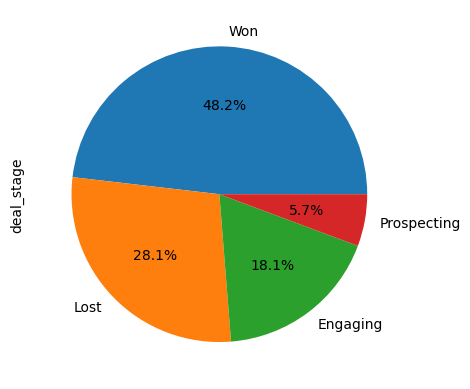

In [16]:
win_rate.plot(kind="pie", autopct = '%2.1f%%')
plt.show()


In [21]:
df['close_date'].count()

6711

In [31]:
#number of sales agents available in the data
len(df["sales_agent"].unique())

36

In [17]:
#total won deal by close value
df[df['deal_stage'] == 'Won'].groupby(['deal_stage'])['close_value'].sum()

deal_stage
Won    10005534
Name: close_value, dtype: int32

In [18]:
#total won deal by revenue
df[df['deal_stage'] == 'Won'].groupby(['deal_stage'])['revenue'].sum()

deal_stage
Won    10576285.17
Name: revenue, dtype: float64

In [19]:
#revenue of sales agents that won deals
s_agent=df[df['deal_stage'] == 'Won'].groupby('sales_agent')['revenue'].sum()
s_agent.sort_values(ascending=False).head()

sales_agent
Kary Hendrixson    676332.07
Vicki Laflamme     673238.73
Darcel Schlecht    649643.56
Kami Bicknell      490899.91
Maureen Marcano    482663.56
Name: revenue, dtype: float64

In [20]:
#total close value of sales agents that won deals
s_agent=df[df['deal_stage'] == 'Won'].groupby('sales_agent')['close_value'].sum()
s_agent.sort_values(ascending=False).head()

sales_agent
Darcel Schlecht    1153214
Vicki Laflamme      478396
Kary Hendrixson     454298
Cassey Cress        450489
Donn Cantrell       445860
Name: close_value, dtype: int32

In [22]:
#number of deal won by sales agents
agent_won_deals=df[df['deal_stage'] == 'Won'].groupby('sales_agent')["close_date"].count()
agent_won_deals.sort_values(ascending=False)

sales_agent
Darcel Schlecht       349
Vicki Laflamme        221
Kary Hendrixson       209
Anna Snelling         208
Versie Hillebrand     176
Kami Bicknell         174
Jonathan Berthelot    171
Cassey Cress          163
Zane Levy             161
Donn Cantrell         158
Reed Clapper          155
Corliss Cosme         150
Maureen Marcano       149
James Ascencio        135
Gladys Colclough      135
Markita Hansen        130
Moses Frase           129
Lajuana Vencill       127
Marty Freudenburg     122
Violet Mclelland      122
Daniell Hammack       114
Hayden Neloms         107
Cecily Lampkin        107
Niesha Huffines       105
Boris Faz             101
Elease Gluck           80
Rosie Papadopoulos     78
Garret Kinder          75
Rosalina Dieter        72
Wilburn Farren         55
Name: close_date, dtype: int64

In [23]:
#number of deal lost by sales agents
agent_lost_deals=df[df['deal_stage'] == 'Lost'].groupby('sales_agent')["close_date"].count()
agent_lost_deals.sort_values(ascending=False)

sales_agent
Darcel Schlecht       204
Anna Snelling         128
Vicki Laflamme        126
Kary Hendrixson       126
Donn Cantrell         117
Lajuana Vencill       104
Zane Levy             100
Cassey Cress           98
Kami Bicknell          98
Gladys Colclough       97
Markita Hansen         97
Jonathan Berthelot     93
Versie Hillebrand      88
Reed Clapper           82
Corliss Cosme          79
Daniell Hammack        73
Marty Freudenburg      72
James Ascencio         71
Violet Mclelland       71
Niesha Huffines        70
Moses Frase            66
Maureen Marcano        64
Cecily Lampkin         53
Boris Faz              52
Garret Kinder          48
Elease Gluck           46
Hayden Neloms          45
Rosie Papadopoulos     43
Rosalina Dieter        38
Wilburn Farren         24
Name: close_date, dtype: int64

In [24]:
df.columns

Index(['opportunity_id', 'sales_agent', 'product', 'account', 'deal_stage',
       'engage_date', 'close_date', 'close_value', 'sector',
       'year_established', 'revenue', 'employees', 'office_location',
       'manager', 'regional_office', 'series', 'sales_price'],
      dtype='object')

In [25]:
#number of deal won by manager
agent_won_deals=df[df['deal_stage'] == 'Won'].groupby('manager')["close_date"].count()
agent_won_deals.sort_values(ascending=False)

manager
Melvin Marxen       882
Summer Sewald       828
Dustin Brinkmann    747
Rocco Neubert       691
Celia Rouche        610
Cara Losch          480
Name: close_date, dtype: int64

In [26]:
#number of sales agents alocated to the managers  
manager_cv=df.groupby('manager')['sales_agent'].value_counts()
manager_cv#.sort_values(ascending=False)


manager           sales_agent       
Cara Losch        Corliss Cosme         310
                  Violet Mclelland      261
                  Rosie Papadopoulos    160
                  Garret Kinder         123
                  Wilburn Farren        110
                  Elizabeth Anderson      1
Celia Rouche      Vicki Laflamme        451
                  Markita Hansen        306
                  Hayden Neloms         202
                  Elease Gluck          177
                  Rosalina Dieter       160
                  Carol Thompson          1
Dustin Brinkmann  Anna Snelling         448
                  Versie Hillebrand     361
                  Lajuana Vencill       311
                  Moses Frase           260
                  Cecily Lampkin        203
Melvin Marxen     Darcel Schlecht       747
                  Jonathan Berthelot    345
                  Gladys Colclough      317
                  Marty Freudenburg     281
                  Niesha Huffines      

In [27]:
#close value percentage of deals won by managers
manager_cv=round((df[df['deal_stage'] == 'Won'].groupby('manager')['close_value'].sum()/10005534)*100,0)
manager_cv.sort_values(ascending=False)

manager
Melvin Marxen       23.0
Rocco Neubert       20.0
Summer Sewald       20.0
Celia Rouche        16.0
Cara Losch          11.0
Dustin Brinkmann    11.0
Name: close_value, dtype: float64

In [28]:
#number of managers allocated to office location 
manager_off=df[df['deal_stage'] == 'Won'].groupby('office_location')['manager'].value_counts()
manager_off#.sort_values(ascending=False)

office_location  manager         
Belgium          Melvin Marxen        36
                 Dustin Brinkmann     27
Brazil           Summer Sewald        23
                 Celia Rouche          9
China            Rocco Neubert        20
                 Cara Losch           13
Germany          Summer Sewald        25
                 Celia Rouche         12
Italy            Melvin Marxen        30
                 Dustin Brinkmann     24
Japan            Rocco Neubert        28
                 Cara Losch           18
Jordan           Rocco Neubert        31
                 Cara Losch           21
Kenya            Dustin Brinkmann     28
                 Melvin Marxen        25
Korea            Summer Sewald        30
                 Celia Rouche         28
                 Dustin Brinkmann     28
                 Melvin Marxen        25
Norway           Melvin Marxen        32
                 Dustin Brinkmann     18
Panama           Melvin Marxen        38
                 Dustin

In [29]:
df.describe()

,close_value,year_established,revenue,employees,sales_price
count,8806.000000,8806.0,8806.000000,8806.000000,8806.000000
mean,1136.217806,1970.0,2066.537256,5342.209970,1567.784011
std,2123.012311,0.0,2544.262269,6291.230461,2490.562880
min,0.000000,1970.0,0.000000,9.000000,0.000000
25%,0.000000,1970.0,223.800000,1588.000000,55.000000
50%,0.000000,1970.0,1188.420000,3492.000000,550.000000
75%,1084.000000,1970.0,2819.500000,6472.000000,3393.000000
max,30288.000000,1970.0,11698.030000,34288.000000,26768.000000


In [56]:
#total close value won by the different sales agent 
df.groupby(["sales_agent","deal_stage"])["close_value"].sum().sort_values(ascending=False).head(60)

sales_agent         deal_stage 
Darcel Schlecht     Won            1153214
Vicki Laflamme      Won             478396
Kary Hendrixson     Won             454298
Cassey Cress        Won             450489
Donn Cantrell       Won             445860
Reed Clapper        Won             438336
Zane Levy           Won             430068
Corliss Cosme       Won             421036
James Ascencio      Won             413533
Daniell Hammack     Won             364229
Maureen Marcano     Won             350395
Gladys Colclough    Won             345674
Markita Hansen      Won             328792
Kami Bicknell       Won             316456
Marty Freudenburg   Won             291195
Elease Gluck        Won             289195
Jonathan Berthelot  Won             284886
Anna Snelling       Won             275056
Hayden Neloms       Won             272111
Boris Faz           Won             261631
Rosalina Dieter     Won             235403
Rosie Papadopoulos  Won             230169
Cecily Lampkin      Wo

2. Deal Funnel & Conversion Rate

Conversion Funnel

Prospecting → Engaging → Won/Lost

In [15]:
df["deal_stage"].value_counts()

Won            4238
Lost           2473
Engaging       1589
Prospecting     500
Name: deal_stage, dtype: int64

Deal Stage	Count	Description

Won	4238	Successfully closed deals ✅

Lost	2473	Opportunities that failed to close ❌

Engaging	1589	Currently in discussion or negotiation 🤝

Prospecting	500	Still identifying potential interest 🔍

In [36]:
#sales agent with number of unique stages 
product_stages_s = df.groupby('sales_agent')['deal_stage'].nunique()#.sort_values(ascending=False)
product_stages_s

sales_agent
Anna Snelling         4
Boris Faz             3
Carl Lin              0
Carol Thompson        0
Cassey Cress          3
Cecily Lampkin        4
Corliss Cosme         3
Daniell Hammack       3
Darcel Schlecht       4
Donn Cantrell         2
Elease Gluck          3
Elizabeth Anderson    0
Garret Kinder         2
Gladys Colclough      4
Hayden Neloms         3
James Ascencio        3
Jonathan Berthelot    4
Kami Bicknell         3
Kary Hendrixson       3
Lajuana Vencill       4
Markita Hansen        3
Marty Freudenburg     4
Maureen Marcano       3
Mei-Mei Johns         0
Moses Frase           4
Natalya Ivanova       0
Niesha Huffines       4
Reed Clapper          2
Rosalina Dieter       3
Rosie Papadopoulos    3
Versie Hillebrand     4
Vicki Laflamme        3
Violet Mclelland      3
Wilburn Farren        3
Zane Levy             3
Name: deal_stage, dtype: int64

3. Deal Funnel on Product

In [32]:
#product with number of order
df["product"].value_counts()

GTX Basic         1866
MG Special        1651
GTXPro            1480
MG Advanced       1412
GTX Plus Basic    1383
GTX Plus Pro       968
GTK 500             40
GTX Pro              1
Name: product, dtype: int64

In [33]:
df["product"]=df["product"].str.replace('GTXPro','GTX Pro')
df["product"].dropna(inplace=True)

In [34]:
#number of product by the deal stages
df.groupby(["product","deal_stage"])["close_value"].count().sort_values(ascending=False).head(60)

product         deal_stage 
GTX Basic       Won            915
MG Special      Won            793
GTX Pro         Won            729
MG Advanced     Won            654
GTX Plus Basic  Won            653
GTX Basic       Lost           521
GTX Plus Pro    Won            479
MG Advanced     Lost           430
MG Special      Lost           430
GTX Pro         Lost           418
GTX Plus Basic  Lost           398
GTX Basic       Engaging       337
MG Special      Engaging       308
GTX Plus Pro    Lost           266
GTX Plus Basic  Engaging       258
GTX Pro         Engaging       253
MG Advanced     Engaging       242
GTX Plus Pro    Engaging       176
MG Special      Prospecting    120
GTX Basic       Prospecting     93
MG Advanced     Prospecting     86
GTX Pro         Prospecting     80
GTX Plus Basic  Prospecting     74
GTX Plus Pro    Prospecting     47
GTK 500         Won             15
                Engaging        15
                Lost            10
Name: close_value, dtype: i

In [35]:
product_stages = df.groupby('product')['deal_stage'].unique()#.sort_values(ascending=False)
product_stages

product
GTK 500                             [Lost, Won, Engaging]
GTX Basic              [Lost, Won, Prospecting, Engaging]
GTX Plus Basic         [Won, Lost, Engaging, Prospecting]
GTX Plus Pro           [Won, Lost, Engaging, Prospecting]
GTX Pro           [nan, Won, Lost, Engaging, Prospecting]
MG Advanced            [Prospecting, Won, Lost, Engaging]
MG Special             [Lost, Won, Prospecting, Engaging]
Name: deal_stage, dtype: object

In [37]:
#a pivot table showing the product and the aggregate according to deal stages
stage_counts = df.pivot_table(index='product', columns='deal_stage',aggfunc='size', fill_value=0)
stage_counts

deal_stage,Engaging,Lost,Prospecting,Won
product,,,,
GTK 500,15,10,0,15
GTX Basic,337,521,93,915
GTX Plus Basic,258,398,74,653
GTX Plus Pro,176,266,47,479
GTX Pro,253,418,80,729
MG Advanced,242,430,86,654
MG Special,308,430,120,793


In [38]:
#subtracting the number of engaged product from that of won
stage_counts['Won_minus_Engaging'] = stage_counts['Won'] - stage_counts['Engaging']
stage_counts

deal_stage,Engaging,Lost,Prospecting,Won,Won_minus_Engaging
product,,,,,
GTK 500,15,10,0,15,0
GTX Basic,337,521,93,915,578
GTX Plus Basic,258,398,74,653,395
GTX Plus Pro,176,266,47,479,303
GTX Pro,253,418,80,729,476
MG Advanced,242,430,86,654,412
MG Special,308,430,120,793,485


In [39]:
#subtracting the number of lost product from that of engaged
stage_counts['lost_minus_Engaging']=stage_counts['Lost'] - stage_counts['Engaging']
stage_counts

deal_stage,Engaging,Lost,Prospecting,Won,Won_minus_Engaging,lost_minus_Engaging
product,,,,,,
GTK 500,15,10,0,15,0,-5
GTX Basic,337,521,93,915,578,184
GTX Plus Basic,258,398,74,653,395,140
GTX Plus Pro,176,266,47,479,303,90
GTX Pro,253,418,80,729,476,165
MG Advanced,242,430,86,654,412,188
MG Special,308,430,120,793,485,122


3. Average Time to close a deal

In [41]:
#number of days it takes to close a deal
duration=df['close_date']-df['engage_date']
#the average 
duration.sort_values(ascending=False).mean()

Timedelta('47 days 23:38:58.310236924')

In [42]:
print(duration.max())
print(duration.min())

138 days 00:00:00
1 days 00:00:00


4. Sector Segmentation

In [45]:
#grouping sector by other attributes
df.groupby(["sector"])['employees', 'revenue','year_established','close_value'].mean().sort_values("revenue", ascending=False)

C:\Users\HP\AppData\Local\Temp\ipykernel_7732\279672392.py:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  df.groupby(["sector"])['employees', 'revenue','year_established','close_value'].mean().sort_values("revenue", ascending=False)


,employees,revenue,year_established,close_value
sector,,,,
software,14898.454425,5661.234174,1970.0,1423.955086
technolgy,6924.266094,3483.314026,1970.0,1300.847210
telecommunications,7055.828343,2878.900100,1970.0,1304.538922
finance,5434.734513,2201.620354,1970.0,1402.519174
entertainment,3547.669623,1944.497051,1970.0,1527.731707
marketing,4365.749258,1753.539258,1970.0,1368.428783
retail,3720.600573,1684.935977,1970.0,1336.813171
employment,4530.241158,1672.734887,1970.0,1402.488746
medical,3083.540438,1488.562607,1970.0,1293.620362


In [46]:
df['year_established'].unique()

array([1970], dtype=int64)

In [61]:
#grouping office location by other attributes
df.groupby(["office_location"])['employees', 'revenue','year_established','close_value'].mean()

C:\Users\HP\AppData\Local\Temp\ipykernel_7732\1143263363.py:2: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  df.groupby(["office_location"])['employees', 'revenue','year_established','close_value'].mean()


,employees,revenue,year_established,close_value
office_location,,,,
Belgium,1165.000000,1376.800000,1970.0,1077.642202
Brazil,1179.000000,405.590000,1970.0,1034.475410
China,142.000000,40.790000,1970.0,1494.655172
Germany,3492.000000,1012.720000,1970.0,1502.218182
Italy,1635.000000,894.330000,1970.0,1216.510638
Japan,17479.000000,5158.710000,1970.0,1524.765432
Jordan,9516.000000,3027.460000,1970.0,1856.125000
Kenya,1185.000000,647.180000,1970.0,1167.478261
Korea,16499.000000,8170.380000,1970.0,974.785000


6. Regional Sales Insights 

In [64]:
regional_goal = df.groupby('regional_office').agg({
    'deal_stage': ['unique'],
    'close_value':['mean']
})
regional_goal

,deal_stage,close_value
,unique,mean
regional_office,,
Central,"[Lost, Engaging, Won, Prospecting, nan]",952.545687
East,"[Lost, Won, Engaging, nan]",1347.838639
West,"[Lost, Won, Engaging, nan]",1189.945649


8. Product Demand Analysis 

In [68]:
df.groupby(['product'])['close_value','sales_price'].mean()

C:\Users\HP\AppData\Local\Temp\ipykernel_7732\2246840654.py:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  df.groupby(['product'])['close_value','sales_price'].mean()


,close_value,sales_price
product,,
GTK 500,10015.300000,26768.000000
GTX Basic,267.557878,550.000000
GTX Plus Basic,509.960231,1096.000000
GTX Plus Pro,2716.581612,5482.000000
GTX Pro,2370.410533,3.255233
MG Advanced,1569.679178,3393.000000
MG Special,26.509994,55.000000


In [69]:
df['close_value'].corr(df['sales_price'])

0.38712179739739133

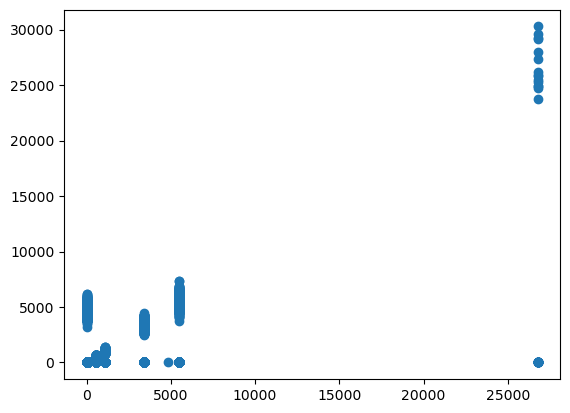

In [53]:
plt.scatter(df['sales_price'],df['close_value'])
plt.show()